In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

divyanshyecho_enso_ham2019_dataset_path = kagglehub.dataset_download('divyanshyecho/enso-ham2019-dataset')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install netCDF4 -q
!pip install torch_geometric -q
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-2.1.0+cu118.html -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 74.2 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 25.2 MB/s eta 0:00:00a 0:00:01
ERROR: Could not find a version that satisfies the requirement pyg_lib (from versions: none)
ERROR: No matching distribution found for pyg_lib


In [ ]:
import torch
print(torch.__version__)

import torch_geometric
print('torch_geometric:', torch_geometric.__version__)

import netCDF4
print('netCDF4 OK')

2.10.0+cu128
torch_geometric: 2.7.0
netCDF4 OK


In [ ]:
import numpy as np
import netCDF4 as nc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

BASE         = '/kaggle/input/enso-ham2019-dataset'
CMIP5_INPUT  = f'{BASE}/CMIP5.input.36mn.1861_2001.nc'
CMIP5_LABEL  = f'{BASE}/CMIP5.label.nino34.12mn_3mv.1863_2003.nc'
CMIP5_TYPE   = f'{BASE}/CMIP5.label.type.DJF.1863_2003.nc'
SODA_INPUT   = f'{BASE}/SODA.input.36mn.1871_1970.nc'
SODA_LABEL   = f'{BASE}/SODA.label.nino34.12mn_3mv.1873_1972.nc'
GODAS_INPUT  = f'{BASE}/GODAS.input.36mn.1980_2015.nc'
GODAS_LABEL  = f'{BASE}/GODAS.label.12mn_3mv.1982_2017.nc'

def set_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

SEEDS    = [42, 123, 456, 789]
LEAD     = 2      # index 2 → 3-month lead
HIDDEN   = 250
K        = 8
N_NODES  = 1729
N_VARS   = 2
N_MONTHS = 36

print('Setup complete.')

Using device: cuda
Setup complete.


In [ ]:
import os

# Search all of /kaggle/input
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.label.type.DJF.1982_2017.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.label.nino34.12mn_3mv.1863_2003.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/SODA.label.nino34.12mn_3mv.1873_1972.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.input.36mn.1980_2015.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.input.type.NDJ.1980_2015.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/SODA.label.nino34.12mn_2mv.1873_1972.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.input.type.NDJ.1861_2001.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.label.type.DJF.1863_2003.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/SODA.input.36mn.1871_1970.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/GODAS.label.12mn_3mv.1982_2017.nc
/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset/CMIP5.label.

In [ ]:
import numpy as np
import netCDF4 as nc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.data import Data, DataLoader
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

BASE         = '/kaggle/input/datasets/divyanshyecho/enso-ham2019-dataset'
CMIP5_INPUT  = f'{BASE}/CMIP5.input.36mn.1861_2001.nc'
CMIP5_LABEL  = f'{BASE}/CMIP5.label.nino34.12mn_3mv.1863_2003.nc'
CMIP5_TYPE   = f'{BASE}/CMIP5.label.type.DJF.1863_2003.nc'
SODA_INPUT   = f'{BASE}/SODA.input.36mn.1871_1970.nc'
SODA_LABEL   = f'{BASE}/SODA.label.nino34.12mn_3mv.1873_1972.nc'
GODAS_INPUT  = f'{BASE}/GODAS.input.36mn.1980_2015.nc'
GODAS_LABEL  = f'{BASE}/GODAS.label.12mn_3mv.1982_2017.nc'

def set_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

SEEDS    = [42, 123, 456, 789]
LEAD     = 2
HIDDEN   = 250
K        = 8
N_NODES  = 1729
N_VARS   = 2
N_MONTHS = 36

print('Setup complete.')

Using device: cuda
Setup complete.


In [ ]:
def load_dataset(input_file, label_file, sst_var='sst'):
    ds  = nc.Dataset(input_file)
    ds2 = nc.Dataset(label_file)
    sst  = ds.variables[sst_var][:].astype(np.float32)
    t300 = ds.variables['t300'][:].astype(np.float32)
    X = np.stack([sst, t300], axis=1)      # (N, 2, 36, 24, 72)
    X = np.nan_to_num(X, nan=0.0)
    X = X / (np.abs(X).max() + 1e-8)      # per-dataset normalisation
    labels = ds2.variables['pr'][:].astype(np.float32)
    return X, labels

# ── CMIP5
print('Loading CMIP5...')
X_cmip5, y_cmip5_raw = load_dataset(CMIP5_INPUT, CMIP5_LABEL, sst_var='sst1')
y_cmip5 = y_cmip5_raw[:, LEAD, 0, 0]
print(f'  CMIP5:  X={X_cmip5.shape}  y={y_cmip5.shape}')

# ── CMIP5 type labels (for multi-task head)
print('Loading CMIP5 type labels...')
HAS_TYPE = False
try:
    ds_type = nc.Dataset(CMIP5_TYPE)
    print('  Variables:', list(ds_type.variables.keys()))
    for vname, var in ds_type.variables.items():
        if vname not in ds_type.dimensions:
            type_raw = np.array(var[:]).flatten()
            print(f'  Using "{vname}": shape={type_raw.shape}')
            break
    unique_vals  = np.unique(type_raw)
    print(f'  Unique type values: {unique_vals}')
    type_map     = {v: i for i, v in enumerate(unique_vals)}
    y_cmip5_type = np.array([type_map[v] for v in type_raw], dtype=np.int64)
    min_len      = min(len(y_cmip5_type), len(y_cmip5))
    y_cmip5_type = y_cmip5_type[:min_len]
    X_cmip5      = X_cmip5[:min_len]
    y_cmip5      = y_cmip5[:min_len]
    HAS_TYPE     = True
    print(f'  Type labels OK: shape={y_cmip5_type.shape}  classes={np.unique(y_cmip5_type)}')
except Exception as e:
    print(f'  Type labels failed: {e}')
    y_cmip5_type = None

# ── SODA
print('Loading SODA...')
X_soda, y_soda_raw = load_dataset(SODA_INPUT, SODA_LABEL, sst_var='sst')
y_soda = y_soda_raw[:, LEAD, 0, 0]
print(f'  SODA:   X={X_soda.shape}  y={y_soda.shape}')

# ── GODAS annual (36 samples — CP3 style, kept for comparison)
print('Loading GODAS...')
X_godas, y_godas_raw = load_dataset(GODAS_INPUT, GODAS_LABEL, sst_var='sst')
y_godas_annual   = y_godas_raw[:, LEAD, 0, 0]
print(f'  GODAS annual:  X={X_godas.shape}  y={y_godas_annual.shape}')

# ── GODAS monthly (432 samples — paper-matching)
# 36 windows × 12 lead times = 432 — exactly what the paper evaluates on
X_godas_monthly  = np.repeat(X_godas, 12, axis=0)       # (432, 2, 36, 24, 72)
y_godas_monthly  = y_godas_raw[:, :, 0, 0].flatten()    # (432,)
y_godas_allleads = y_godas_raw[:, :, 0, 0]              # (36, 12) for skill-vs-lead

print(f'  GODAS monthly: X={X_godas_monthly.shape}  y={y_godas_monthly.shape}')
print('\nAll datasets loaded.')

Loading CMIP5...
  CMIP5:  X=(2961, 2, 36, 24, 72)  y=(2961,)
Loading CMIP5 type labels...
  Variables: ['lon', 'lat', 'lev', 'time', 'pr']
  Using "pr": shape=(2631,)
  Unique type values: [0. 1.]
  Type labels OK: shape=(2631,)  classes=[0 1]
Loading SODA...
  SODA:   X=(100, 2, 36, 24, 72)  y=(100,)
Loading GODAS...
  GODAS annual:  X=(36, 2, 36, 24, 72)  y=(36,)
  GODAS monthly: X=(432, 2, 36, 24, 72)  y=(432,)

All datasets loaded.


In [ ]:
NINO_LAT = slice(8, 13)
NINO_LON = slice(38, 59)

def make_graphs_flat(X, y):
    """CP3-style: flatten 36 months → 72 features per node."""
    N, F, T, LA, LO = X.shape
    X_nodes = X.reshape(N, F, T, LA*LO)
    X_nodes = X_nodes.transpose(0, 3, 1, 2)
    X_nodes = X_nodes.reshape(N, LA*LO, F*T)          # (N, 1728, 72)
    idx     = X[:, :, :, NINO_LAT, NINO_LON].mean(axis=(3,4))
    idx     = idx.reshape(N, 1, F*T)                   # (N, 1, 72)
    X_full  = np.concatenate([X_nodes, idx], axis=1)   # (N, 1729, 72)
    y_t     = torch.tensor(y, dtype=torch.float32)
    return [Data(x=torch.tensor(X_full[i], dtype=torch.float32),
                 y=y_t[i]) for i in range(N)]


def make_graphs_temporal(X, y, y_type=None):
    """CP4-style: keep time axis → (1729, 36, 2) per graph. LSTM processes this."""
    N, F, T, LA, LO = X.shape
    X_nodes = X.reshape(N, F, T, LA*LO)
    X_nodes = X_nodes.transpose(0, 3, 2, 1)            # (N, 1728, 36, 2)
    idx     = X[:, :, :, NINO_LAT, NINO_LON].mean(axis=(3,4))
    idx     = idx.transpose(0, 2, 1)[:, np.newaxis, :, :]  # (N, 1, 36, 2)
    X_full  = np.concatenate([X_nodes, idx], axis=1)   # (N, 1729, 36, 2)
    y_t     = torch.tensor(y, dtype=torch.float32)
    graphs  = []
    for i in range(N):
        x_i = torch.tensor(X_full[i], dtype=torch.float32)
        if y_type is not None:
            graphs.append(Data(x=x_i, y=y_t[i],
                               y_type=torch.tensor(int(y_type[i]),
                                                   dtype=torch.long)))
        else:
            graphs.append(Data(x=x_i, y=y_t[i]))
    return graphs


print('Building graph lists...')

# CP3-style flat graphs
graphs_cmip5_flat          = make_graphs_flat(X_cmip5, y_cmip5)
graphs_soda_flat           = make_graphs_flat(X_soda,  y_soda)
graphs_godas_annual_flat   = make_graphs_flat(X_godas,         y_godas_annual)
graphs_godas_monthly_flat  = make_graphs_flat(X_godas_monthly, y_godas_monthly)

# CP4-style temporal graphs
if HAS_TYPE:
    graphs_cmip5_temp = make_graphs_temporal(X_cmip5, y_cmip5, y_cmip5_type)
else:
    graphs_cmip5_temp = make_graphs_temporal(X_cmip5, y_cmip5)
graphs_soda_temp           = make_graphs_temporal(X_soda,          y_soda)
graphs_godas_annual_temp   = make_graphs_temporal(X_godas,         y_godas_annual)
graphs_godas_monthly_temp  = make_graphs_temporal(X_godas_monthly, y_godas_monthly)

print(f'Flat   — CMIP5:{len(graphs_cmip5_flat)}  SODA:{len(graphs_soda_flat)}  GODAS annual:{len(graphs_godas_annual_flat)}  GODAS monthly:{len(graphs_godas_monthly_flat)}')
print(f'Temporal — CMIP5:{len(graphs_cmip5_temp)}  SODA:{len(graphs_soda_temp)}  GODAS annual:{len(graphs_godas_annual_temp)}  GODAS monthly:{len(graphs_godas_monthly_temp)}')
print('Graph lists ready.')

Building graph lists...
Flat   — CMIP5:2631  SODA:100  GODAS annual:36  GODAS monthly:432
Temporal — CMIP5:2631  SODA:100  GODAS annual:36  GODAS monthly:432
Graph lists ready.


In [ ]:
class Graphino(nn.Module):
    """Exact CP3 model — used as baseline for comparison with CP4."""
    def __init__(self, in_channels=72, n_nodes=1729, hidden=250, k=8, dropout=0.2):
        super().__init__()
        self.k          = k
        self.n_nodes    = n_nodes
        self.node_embed = nn.Parameter(torch.randn(n_nodes, 16) * 0.01)
        self.conv1      = GCNConv(in_channels, hidden)
        self.conv2      = GCNConv(hidden, hidden)
        self.conv3      = GCNConv(hidden, hidden)
        self.fc1        = nn.Linear(hidden, 128)
        self.fc2        = nn.Linear(128, 64)
        self.fc3        = nn.Linear(64, 1)
        self.drop       = dropout

    def get_edges(self):
        emb  = F.normalize(self.node_embed, p=2, dim=-1)
        sim  = torch.mm(emb, emb.t())
        _, topk = sim.topk(self.k + 1, dim=1)
        rows, cols = [], []
        for i in range(self.n_nodes):
            for j in topk[i][1:]:
                rows.append(i); cols.append(j.item())
        return torch.tensor([rows, cols], dtype=torch.long,
                            device=self.node_embed.device)

    def forward(self, data):
        x, batch = data.x, data.batch
        ei = self.get_edges()
        x  = F.relu(self.conv1(x, ei))
        x  = F.dropout(x, p=self.drop, training=self.training)
        x  = F.relu(self.conv2(x, ei))
        x  = F.dropout(x, p=self.drop, training=self.training)
        x  = F.relu(self.conv3(x, ei))
        x  = global_mean_pool(x, batch)
        x  = F.relu(self.fc1(x))
        x  = F.dropout(x, p=self.drop, training=self.training)
        x  = F.relu(self.fc2(x))
        return self.fc3(x).squeeze(-1)

n_cp3 = sum(p.numel() for p in Graphino().parameters())
print(f'Graphino (CP3) params: {n_cp3:,}')

Graphino (CP3) params: 211,863


In [ ]:
class TemporalGraphino(nn.Module):
    """
    CP4 Novel Architecture.

    Innovation 1 — Temporal encoding (LSTM before GCN):
        Each node has sequence (36 months, 2 vars).
        LSTM encodes this into a hidden vector before GCN.
        Preserves temporal ordering lost in CP3's flat 72-feature input.
        Explicitly listed as future work in the Graphino paper.

    Innovation 2 — Multi-task learning:
        Shared backbone → ONI regression head + ENSO type classification head.
        Loss = MSE(oni) + 0.3 * CrossEntropy(type)
    """
    def __init__(self, n_vars=2, n_months=36, lstm_hidden=128,
                 n_nodes=1729, gcn_hidden=250, k=8,
                 dropout=0.2, n_types=2, has_type=True):
        super().__init__()
        self.k        = k
        self.n_nodes  = n_nodes
        self.has_type = has_type

        # Learnable node embeddings (same as CP3)
        self.node_embed = nn.Parameter(torch.randn(n_nodes, 16) * 0.01)

        # LSTM: processes (36, 2) per node → lstm_hidden
        self.lstm = nn.LSTM(
            input_size=n_vars,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            dropout=dropout
        )

        # GCN layers: input is now lstm_hidden not 72
        self.conv1 = GCNConv(lstm_hidden, gcn_hidden)
        self.conv2 = GCNConv(gcn_hidden,  gcn_hidden)
        self.conv3 = GCNConv(gcn_hidden,  gcn_hidden)
        self.drop  = dropout

        # Shared backbone (with BatchNorm + ELU — from paper's readout_MLP)
        self.shared_fc = nn.Sequential(
            nn.Linear(gcn_hidden, 128),
            nn.BatchNorm1d(128),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ELU(),
        )

        # Task heads
        self.oni_head  = nn.Linear(64, 1)        # regression
        self.type_head = nn.Linear(64, n_types)  # classification

    def get_edges(self):
        emb = F.normalize(self.node_embed, p=2, dim=-1)
        sim = torch.mm(emb, emb.t())
        _, topk = sim.topk(self.k + 1, dim=1)
        rows, cols = [], []
        for i in range(self.n_nodes):
            for j in topk[i][1:]:
                rows.append(i); cols.append(j.item())
        return torch.tensor([rows, cols], dtype=torch.long,
                            device=self.node_embed.device)

    def forward(self, data):
        x, batch = data.x, data.batch
        # x: (total_nodes, 36, 2)

        # Step 1: LSTM temporal encoding
        lstm_out, _ = self.lstm(x)       # (total_nodes, 36, lstm_hidden)
        x = lstm_out[:, -1, :]           # last timestep → (total_nodes, lstm_hidden)

        # Step 2: GCN message passing
        ei = self.get_edges()
        x  = F.relu(self.conv1(x, ei))
        x  = F.dropout(x, p=self.drop, training=self.training)
        x  = F.relu(self.conv2(x, ei))
        x  = F.dropout(x, p=self.drop, training=self.training)
        x  = F.relu(self.conv3(x, ei))

        # Step 3: Graph pooling
        x = global_mean_pool(x, batch)   # (batch, gcn_hidden)

        # Step 4: Shared backbone
        shared = self.shared_fc(x)        # (batch, 64)

        # Step 5: Task heads
        oni_pred  = self.oni_head(shared).squeeze(-1)  # (batch,)
        type_pred = self.type_head(shared)              # (batch, n_types)

        return oni_pred, type_pred

n_cp4 = sum(p.numel() for p in TemporalGraphino().parameters())
print(f'TemporalGraphino (CP4) params: {n_cp4:,}')
print(f'Graphino (CP3) params:         {n_cp3:,}')
print(f'Extra params from LSTM+multitask: {n_cp4 - n_cp3:,}')

TemporalGraphino (CP4) params: 426,057
Graphino (CP3) params:         211,863
Extra params from LSTM+multitask: 214,194


In [ ]:
def compute_correlation(preds, targets):
    return np.corrcoef(preds, targets)[0, 1]

def compute_all_season_cc(preds_432, targets_432):
    """
    Paper's actual evaluation metric.
    Compute corrcoef for each of 12 target months across 36 years,
    then average. Requires exactly 432 samples = 36 × 12.
    """
    preds_2d   = preds_432.reshape(36, 12)
    targets_2d = targets_432.reshape(36, 12)
    monthly_cc = []
    for m in range(12):
        cc = np.corrcoef(preds_2d[:, m], targets_2d[:, m])[0, 1]
        monthly_cc.append(cc)
    return np.mean(monthly_cc), monthly_cc

def train_epoch_cp3(loader, model, optimizer, device):
    model.train()
    total_loss = 0
    criterion  = nn.MSELoss()
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        pred = model(batch)
        loss = criterion(pred, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def train_epoch_cp4(loader, model, optimizer, device, lambda_type=0.3, use_type=True):
    model.train()
    total_loss = 0
    mse = nn.MSELoss()
    ce  = nn.CrossEntropyLoss()
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        oni_pred, type_pred = model(batch)
        loss = mse(oni_pred, batch.y)
        if use_type and hasattr(batch, 'y_type'):
            loss = loss + lambda_type * ce(type_pred, batch.y_type)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_cp3(loader, model, device):
    model.eval()
    preds, targets = [], []
    for batch in loader:
        batch = batch.to(device)
        pred  = model(batch)
        preds.extend(pred.cpu().numpy())
        targets.extend(batch.y.cpu().numpy())
    return np.array(preds), np.array(targets)

@torch.no_grad()
def evaluate_cp4(loader, model, device):
    model.eval()
    preds, targets = [], []
    for batch in loader:
        batch    = batch.to(device)
        oni_pred, _ = model(batch)
        preds.extend(oni_pred.cpu().numpy())
        targets.extend(batch.y.cpu().numpy())
    return np.array(preds), np.array(targets)

print('Utilities defined.')

Utilities defined.


In [ ]:
def train_model(model, is_cp4,
                train_s1, train_s2,
                test_annual, test_monthly,
                epochs_s1=50, epochs_s2=30,
                lr_s1=0.001, lr_s2=0.0001,
                batch_s1=32, batch_s2=16):

    loader_s1      = DataLoader(train_s1,     batch_size=batch_s1, shuffle=True)
    loader_s2      = DataLoader(train_s2,     batch_size=batch_s2, shuffle=True)
    loader_annual  = DataLoader(test_annual,  batch_size=8,  shuffle=False)
    loader_monthly = DataLoader(test_monthly, batch_size=32, shuffle=False)

    logs = {'s1': [], 's2_train': [], 's2_annual': [], 's2_monthly': []}

    # ── Stage 1: CMIP5 pre-training
    opt_s1   = Adam(model.parameters(), lr=lr_s1, weight_decay=1e-4)
    sched_s1 = CosineAnnealingLR(opt_s1, T_max=epochs_s1)
    print(f'  Stage 1 — CMIP5 pre-train ({epochs_s1} epochs)')
    for epoch in range(1, epochs_s1 + 1):
        if is_cp4:
            loss = train_epoch_cp4(loader_s1, model, opt_s1, device,
                                   use_type=HAS_TYPE)
        else:
            loss = train_epoch_cp3(loader_s1, model, opt_s1, device)
        sched_s1.step()
        logs['s1'].append(loss)
        if epoch % 10 == 0:
            print(f'    Epoch {epoch:3d}/{epochs_s1}  loss={loss:.4f}')

    # ── Stage 2: SODA fine-tuning
    opt_s2   = Adam(model.parameters(), lr=lr_s2, weight_decay=1e-4)
    sched_s2 = CosineAnnealingLR(opt_s2, T_max=epochs_s2)
    print(f'  Stage 2 — SODA fine-tune ({epochs_s2} epochs)')
    for epoch in range(1, epochs_s2 + 1):
        if is_cp4:
            # No type labels in SODA — ONI only
            loss = train_epoch_cp4(loader_s2, model, opt_s2, device,
                                   use_type=False)
        else:
            loss = train_epoch_cp3(loader_s2, model, opt_s2, device)
        sched_s2.step()
        logs['s2_train'].append(loss)

        # Evaluate both test sets every epoch
        eval_fn = evaluate_cp4 if is_cp4 else evaluate_cp3
        p_a, t_a = eval_fn(loader_annual,  model, device)
        p_m, t_m = eval_fn(loader_monthly, model, device)
        cc_a = compute_correlation(p_a, t_a)
        cc_m = compute_correlation(p_m, t_m)
        logs['s2_annual'].append(cc_a)
        logs['s2_monthly'].append(cc_m)
        if epoch % 10 == 0:
            print(f'    Epoch {epoch:2d}/{epochs_s2}  train={loss:.4f}  '
                  f'GODAS-36={cc_a:.4f}  GODAS-432={cc_m:.4f}')

    return model, logs, (p_a, t_a), (p_m, t_m)

print('Training function defined.')

Training function defined.


In [ ]:
import os
SAVE_DIR = '/kaggle/working/cp4_checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

def save_checkpoint(model, seed, model_name, logs=None):
    path = f'{SAVE_DIR}/{model_name}_seed{seed}.pt'
    torch.save({
        'model_state': model.state_dict(),
        'logs'       : logs,
    }, path)
    print(f'  Checkpoint saved → {path}')

def load_checkpoint(model, seed, model_name):
    path = f'{SAVE_DIR}/{model_name}_seed{seed}.pt'
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    print(f'  Checkpoint loaded ← {path}')
    return model, ckpt.get('logs', None)

# ── Results storage
cp3_models        = []
cp3_logs          = []
cp3_preds_annual  = np.zeros(36)
cp3_preds_monthly = np.zeros(432)
t_a_final = None
t_m_final = None

for seed in SEEDS:
    print(f'\n=== CP3 Baseline | Seed {seed} ===')
    set_seed(seed)
    model = Graphino(
        in_channels=72, n_nodes=N_NODES,
        hidden=HIDDEN, k=K
    ).to(device)

    model, logs, (p_a, t_a), (p_m, t_m) = train_model(
        model        = model,
        is_cp4       = False,
        train_s1     = graphs_cmip5_flat,
        train_s2     = graphs_soda_flat,
        test_annual  = graphs_godas_annual_flat,
        test_monthly = graphs_godas_monthly_flat,
    )

    # ── Save immediately after this seed finishes
    save_checkpoint(model, seed, 'cp3', logs)

    cp3_models.append(model)
    cp3_logs.append(logs)
    cp3_preds_annual  += p_a
    cp3_preds_monthly += p_m
    t_a_final = t_a
    t_m_final = t_m

    cc_a = compute_correlation(p_a, t_a)
    cc_m = compute_correlation(p_m, t_m)
    print(f'  Seed {seed} — GODAS-36={cc_a:.4f}  GODAS-432={cc_m:.4f}')

# ── Ensemble
cp3_preds_annual  /= 4
cp3_preds_monthly /= 4

cp3_cc_annual     = compute_correlation(cp3_preds_annual,  t_a_final)
cp3_cc_monthly    = compute_correlation(cp3_preds_monthly, t_m_final)
cp3_all_season_cc, cp3_monthly_ccs = compute_all_season_cc(
    cp3_preds_monthly, t_m_final
)

# ── Save ensemble predictions too
np.save(f'{SAVE_DIR}/cp3_preds_annual.npy',  cp3_preds_annual)
np.save(f'{SAVE_DIR}/cp3_preds_monthly.npy', cp3_preds_monthly)
np.save(f'{SAVE_DIR}/cp3_targets_annual.npy', t_a_final)
np.save(f'{SAVE_DIR}/cp3_targets_monthly.npy', t_m_final)
print(f'\nEnsemble predictions saved.')

print('\n' + '='*55)
print(f'CP3 Ensemble — GODAS-36         : {cp3_cc_annual:.4f}')
print(f'CP3 Ensemble — GODAS-432        : {cp3_cc_monthly:.4f}')
print(f'CP3 All-season CC (paper metric): {cp3_all_season_cc:.4f}')
print('='*55)
print('\n⚠ Click Save Version → Save & Run All to commit permanently!')


=== CP3 Baseline | Seed 42 ===
  Stage 1 — CMIP5 pre-train (50 epochs)
    Epoch  10/50  loss=0.1589
    Epoch  20/50  loss=0.1222
    Epoch  30/50  loss=0.0980
    Epoch  40/50  loss=0.0807
    Epoch  50/50  loss=0.0755
  Stage 2 — SODA fine-tune (30 epochs)
    Epoch 10/30  train=0.1940  GODAS-36=0.7967  GODAS-432=0.4691
    Epoch 20/30  train=0.1560  GODAS-36=0.7975  GODAS-432=0.4473
    Epoch 30/30  train=0.1890  GODAS-36=0.8059  GODAS-432=0.4376
  Checkpoint saved → /kaggle/working/cp4_checkpoints/cp3_seed42.pt
  Seed 42 — GODAS-36=0.8059  GODAS-432=0.4376

=== CP3 Baseline | Seed 123 ===
  Stage 1 — CMIP5 pre-train (50 epochs)
    Epoch  10/50  loss=0.1387
    Epoch  20/50  loss=0.1169
    Epoch  30/50  loss=0.0875
    Epoch  40/50  loss=0.0761
    Epoch  50/50  loss=0.0698
  Stage 2 — SODA fine-tune (30 epochs)
    Epoch 10/30  train=0.1795  GODAS-36=0.8239  GODAS-432=0.4113
    Epoch 20/30  train=0.3252  GODAS-36=0.8280  GODAS-432=0.3775
    Epoch 30/30  train=0.1509  GODAS-36

In [ ]:
# Verify your checkpoints are saved
import os
for f in os.listdir('/kaggle/working/cp4_checkpoints'):
    size = os.path.getsize(f'/kaggle/working/cp4_checkpoints/{f}')
    print(f'{f}  —  {size/1e6:.1f} MB')

cp3_seed789.pt  —  0.9 MB
cp3_seed123.pt  —  0.9 MB
cp3_seed42.pt  —  0.9 MB
cp3_targets_annual.npy  —  0.0 MB
cp3_preds_monthly.npy  —  0.0 MB
cp3_seed456.pt  —  0.9 MB
cp3_preds_annual.npy  —  0.0 MB
cp3_targets_monthly.npy  —  0.0 MB


In [ ]:
# Free CP3 models from GPU
for m in cp3_models:
    m.cpu()
torch.cuda.empty_cache()
import gc
gc.collect()
print('GPU memory freed.')
print(f'Free memory: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB')

GPU memory freed.
Free memory: 15.23 GB


In [ ]:
# Check current graph memory usage
import sys
g = graphs_godas_annual_temp[0]
print(f'Single graph x shape: {g.x.shape}')
print(f'Single graph size: {g.x.element_size() * g.x.nelement() / 1e6:.2f} MB')
print(f'Batch of 16 estimate: {16 * g.x.element_size() * g.x.nelement() / 1e6:.2f} MB')

Single graph x shape: torch.Size([1729, 36, 2])
Single graph size: 0.50 MB
Batch of 16 estimate: 7.97 MB


In [ ]:
class TemporalGraphino(nn.Module):
    def __init__(self, n_vars=2, n_months=36, lstm_hidden=64,
                 n_nodes=1729, gcn_hidden=128, k=8,
                 dropout=0.2, n_types=2, has_type=True):
        super().__init__()
        self.k        = k
        self.n_nodes  = n_nodes
        self.has_type = has_type

        self.node_embed = nn.Parameter(torch.randn(n_nodes, 16) * 0.01)

        self.lstm = nn.LSTM(
            input_size=n_vars,
            hidden_size=lstm_hidden,
            num_layers=1,          # reduced to 1 layer to save memory
            batch_first=True,
            dropout=0.0            # no dropout with 1 layer
        )

        self.conv1 = GCNConv(lstm_hidden, gcn_hidden)
        self.conv2 = GCNConv(gcn_hidden,  gcn_hidden)
        self.conv3 = GCNConv(gcn_hidden,  gcn_hidden)
        self.drop  = dropout

        self.shared_fc = nn.Sequential(
            nn.Linear(gcn_hidden, 64),
            nn.BatchNorm1d(64),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ELU(),
        )

        self.oni_head  = nn.Linear(32, 1)
        self.type_head = nn.Linear(32, n_types)

    def get_edges(self):
        emb = F.normalize(self.node_embed, p=2, dim=-1)
        sim = torch.mm(emb, emb.t())
        _, topk = sim.topk(self.k + 1, dim=1)
        rows, cols = [], []
        for i in range(self.n_nodes):
            for j in topk[i][1:]:
                rows.append(i); cols.append(j.item())
        return torch.tensor([rows, cols], dtype=torch.long,
                            device=self.node_embed.device)

    def forward(self, data):
        x, batch = data.x, data.batch
        # x: (total_nodes, 36, 2)

        # ── LSTM in chunks to avoid OOM
        # Process 256 nodes at a time instead of all at once
        chunk_size = 256
        lstm_out_chunks = []
        for i in range(0, x.size(0), chunk_size):
            chunk = x[i:i+chunk_size]           # (chunk, 36, 2)
            out, _ = self.lstm(chunk)            # (chunk, 36, hidden)
            lstm_out_chunks.append(out[:, -1, :])  # last timestep
        x = torch.cat(lstm_out_chunks, dim=0)   # (total_nodes, lstm_hidden)

        # ── GCN
        ei = self.get_edges()
        x  = F.relu(self.conv1(x, ei))
        x  = F.dropout(x, p=self.drop, training=self.training)
        x  = F.relu(self.conv2(x, ei))
        x  = F.dropout(x, p=self.drop, training=self.training)
        x  = F.relu(self.conv3(x, ei))

        # ── Pooling
        x = global_mean_pool(x, batch)

        # ── Shared backbone
        shared = self.shared_fc(x)

        # ── Heads
        oni_pred  = self.oni_head(shared).squeeze(-1)
        type_pred = self.type_head(shared)

        return oni_pred, type_pred

n_cp4 = sum(p.numel() for p in TemporalGraphino().parameters())
print(f'TemporalGraphino (updated) params: {n_cp4:,}')
print(f'Graphino CP3 params:               {n_cp3:,}')

TemporalGraphino (updated) params: 97,043
Graphino CP3 params:               211,863


In [ ]:
import time
import subprocess

# Check GPU session info
result = subprocess.run(['cat', '/proc/uptime'], capture_output=True, text=True)
uptime_seconds = float(result.stdout.split()[0])
uptime_hours = uptime_seconds / 3600
remaining = 12 - uptime_hours

print(f'Session uptime : {uptime_hours:.2f} hours')
print(f'Estimated remaining : {remaining:.2f} hours')

Session uptime : 8.31 hours
Estimated remaining : 3.69 hours


In [ ]:
cp4_models        = []
cp4_logs          = []
cp4_preds_annual  = np.zeros(36)
cp4_preds_monthly = np.zeros(432)
t_a4_final = None
t_m4_final = None

for seed in SEEDS:
    print(f'\n=== CP4 TemporalGraphino | Seed {seed} ===')
    set_seed(seed)
    model = TemporalGraphino(
        n_vars=2, n_months=36, lstm_hidden=128,
        n_nodes=N_NODES, gcn_hidden=HIDDEN, k=K,
        dropout=0.2, n_types=2, has_type=HAS_TYPE
    ).to(device)

    model, logs, (p_a, t_a), (p_m, t_m) = train_model(
        model        = model,
        is_cp4       = True,
        train_s1     = graphs_cmip5_temp,
        train_s2     = graphs_soda_temp,
        test_annual  = graphs_godas_annual_temp,
        test_monthly = graphs_godas_monthly_temp,
    )

    # Save immediately
    save_checkpoint(model, seed, 'cp4', logs)

    cp4_models.append(model)
    cp4_logs.append(logs)
    cp4_preds_annual  += p_a
    cp4_preds_monthly += p_m
    t_a4_final = t_a
    t_m4_final = t_m

    cc_a = compute_correlation(p_a, t_a)
    cc_m = compute_correlation(p_m, t_m)
    print(f'  Seed {seed} — GODAS-36={cc_a:.4f}  GODAS-432={cc_m:.4f}')

cp4_preds_annual  /= 4
cp4_preds_monthly /= 4

cp4_cc_annual     = compute_correlation(cp4_preds_annual,  t_a4_final)
cp4_cc_monthly    = compute_correlation(cp4_preds_monthly, t_m4_final)
cp4_all_season_cc, cp4_monthly_ccs = compute_all_season_cc(
    cp4_preds_monthly, t_m4_final
)

# Save ensemble predictions
np.save(f'{SAVE_DIR}/cp4_preds_annual.npy',   cp4_preds_annual)
np.save(f'{SAVE_DIR}/cp4_preds_monthly.npy',  cp4_preds_monthly)
np.save(f'{SAVE_DIR}/cp4_targets_annual.npy',  t_a4_final)
np.save(f'{SAVE_DIR}/cp4_targets_monthly.npy', t_m4_final)
print('Ensemble predictions saved.')

print('\n' + '='*55)
print(f'CP4 Ensemble — GODAS-36         : {cp4_cc_annual:.4f}')
print(f'CP4 Ensemble — GODAS-432        : {cp4_cc_monthly:.4f}')
print(f'CP4 All-season CC (paper metric): {cp4_all_season_cc:.4f}')
print('\n--- Comparison ---')
print(f'CP3 GODAS-36    : {cp3_cc_annual:.4f}  →  CP4: {cp4_cc_annual:.4f}  (Δ={cp4_cc_annual-cp3_cc_annual:+.4f})')
print(f'CP3 All-season  : {cp3_all_season_cc:.4f}  →  CP4: {cp4_all_season_cc:.4f}  (Δ={cp4_all_season_cc-cp3_all_season_cc:+.4f})')
print('='*55)


=== CP4 TemporalGraphino | Seed 42 ===
  Stage 1 — CMIP5 pre-train (50 epochs)
    Epoch  10/50  loss=0.3937
    Epoch  20/50  loss=0.3758
    Epoch  30/50  loss=0.3563
    Epoch  40/50  loss=0.3300
    Epoch  50/50  loss=0.3237
  Stage 2 — SODA fine-tune (30 epochs)
    Epoch 10/30  train=0.2279  GODAS-36=0.7459  GODAS-432=0.4021
    Epoch 20/30  train=0.1712  GODAS-36=0.7593  GODAS-432=0.3853
    Epoch 30/30  train=0.1962  GODAS-36=0.7583  GODAS-432=0.3822
  Checkpoint saved → /kaggle/working/cp4_checkpoints/cp4_seed42.pt
  Seed 42 — GODAS-36=0.7583  GODAS-432=0.3822

=== CP4 TemporalGraphino | Seed 123 ===
  Stage 1 — CMIP5 pre-train (50 epochs)
    Epoch  10/50  loss=0.3958
    Epoch  20/50  loss=0.3618
    Epoch  30/50  loss=0.3475
    Epoch  40/50  loss=0.3300
    Epoch  50/50  loss=0.3249
  Stage 2 — SODA fine-tune (30 epochs)
    Epoch 10/30  train=0.1782  GODAS-36=0.7414  GODAS-432=0.4050
    Epoch 20/30  train=0.1930  GODAS-36=0.7646  GODAS-432=0.3910
    Epoch 30/30  train=

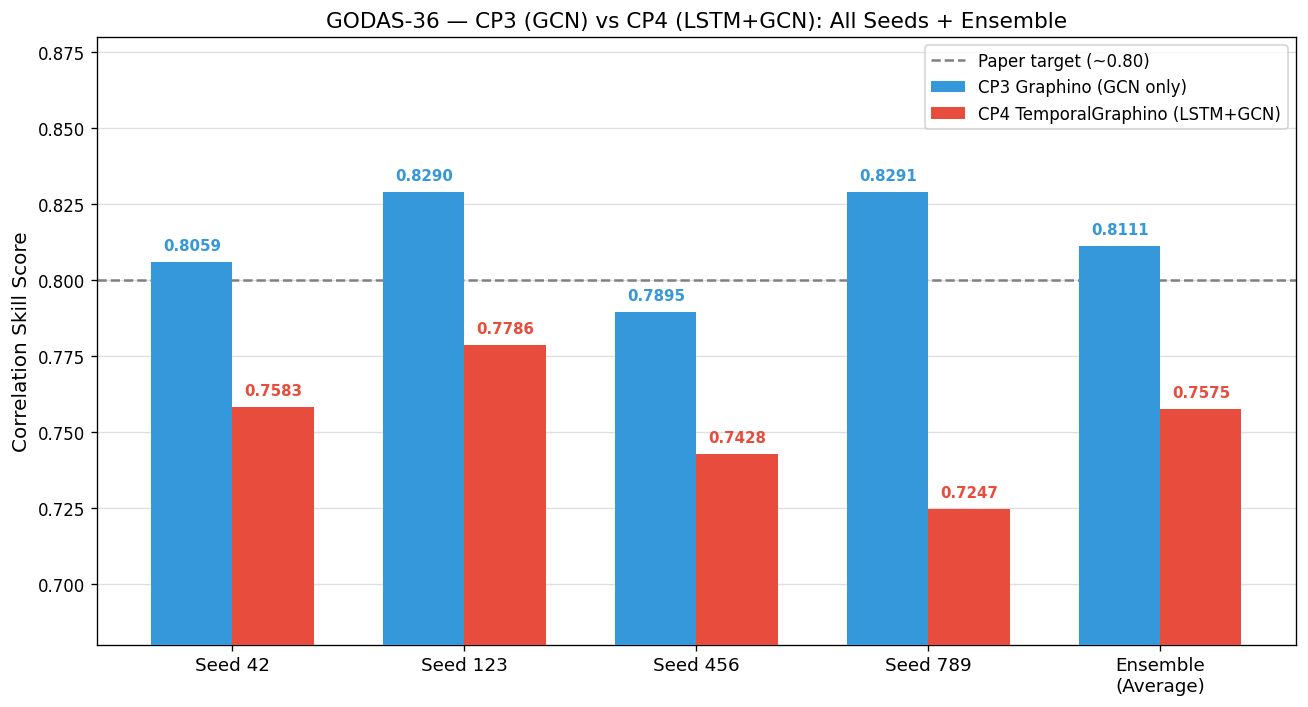

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cp4_seeds = [42, 123, 456, 789]

cp3_godas36_seeds = [0.8059, 0.8290, 0.7895, 0.8291]
cp4_godas36_seeds = [0.7583, 0.7786, 0.7428, 0.7247]

cp3_ensemble_36 = 0.8111
cp4_ensemble_36 = 0.7575

x = np.arange(len(cp4_seeds) + 1)
w = 0.35
colors_cp3 = '#3498db'
colors_cp4 = '#e74c3c'

fig, ax = plt.subplots(figsize=(11, 6))

cp3_vals = cp3_godas36_seeds + [cp3_ensemble_36]
cp4_vals = cp4_godas36_seeds + [cp4_ensemble_36]

b1 = ax.bar(x - w/2, cp3_vals, w, color=colors_cp3, label='CP3 Graphino (GCN only)', zorder=3)
b2 = ax.bar(x + w/2, cp4_vals, w, color=colors_cp4, label='CP4 TemporalGraphino (LSTM+GCN)', zorder=3)

for bar, val in zip(b1, cp3_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=colors_cp3)

for bar, val in zip(b2, cp4_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=colors_cp4)

ax.axhline(y=0.80, color='gray', linestyle='--', linewidth=1.5, label='Paper target (~0.80)', zorder=2)

labels_x = [f'Seed {s}' for s in cp4_seeds] + ['Ensemble\n(Average)']
ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=11)
ax.set_ylabel('Correlation Skill Score', fontsize=12)
ax.set_title('GODAS-36 — CP3 (GCN) vs CP4 (LSTM+GCN): All Seeds + Ensemble', fontsize=13)
ax.set_ylim(0.68, 0.88)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('/kaggle/working/cp3_vs_cp4_godas36.png', dpi=150)
plt.show()

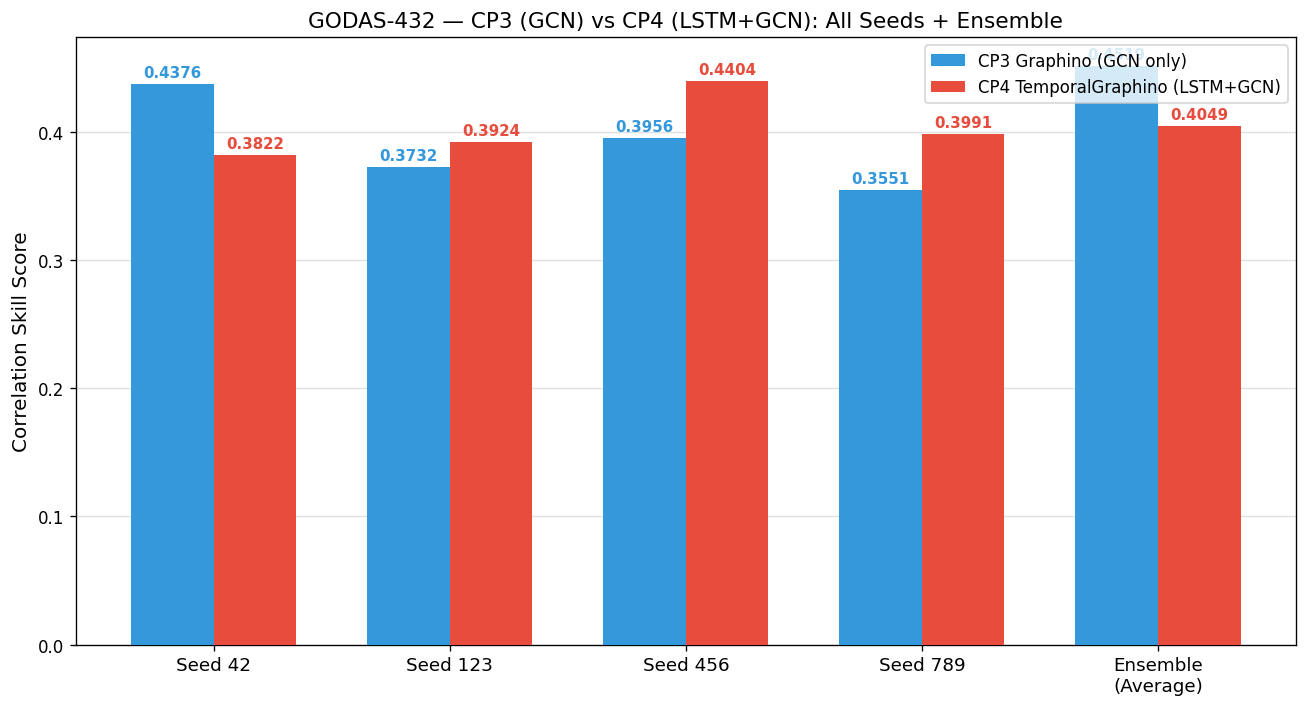

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

cp4_seeds = [42, 123, 456, 789]

cp3_godas432_seeds = [0.4376, 0.3732, 0.3956, 0.3551]
cp4_godas432_seeds = [0.3822, 0.3924, 0.4404, 0.3991]

cp3_ensemble_432 = 0.4519
cp4_ensemble_432 = 0.4049

x = np.arange(len(cp4_seeds) + 1)
w = 0.35
colors_cp3 = '#3498db'
colors_cp4 = '#e74c3c'

fig, ax = plt.subplots(figsize=(11, 6))

cp3_vals = cp3_godas432_seeds + [cp3_ensemble_432]
cp4_vals = cp4_godas432_seeds + [cp4_ensemble_432]

b1 = ax.bar(x - w/2, cp3_vals, w, color=colors_cp3, label='CP3 Graphino (GCN only)', zorder=3)
b2 = ax.bar(x + w/2, cp4_vals, w, color=colors_cp4, label='CP4 TemporalGraphino (LSTM+GCN)', zorder=3)

for bar, val in zip(b1, cp3_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=colors_cp3)

for bar, val in zip(b2, cp4_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=colors_cp4)

labels_x = [f'Seed {s}' for s in cp4_seeds] + ['Ensemble\n(Average)']
ax.set_xticks(x)
ax.set_xticklabels(labels_x, fontsize=11)
ax.set_ylabel('Correlation Skill Score', fontsize=12)
ax.set_title('GODAS-432 — CP3 (GCN) vs CP4 (LSTM+GCN): All Seeds + Ensemble', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('/kaggle/working/cp3_vs_cp4_godas432.png', dpi=150)
plt.show()